# Progetto di Apprendimento Automatico e Apprendimento Profondo
# Studente: Tommaso Cippone
# Matricola: 0322500110

## Classificazione del dataset Breast Cancer Wisconsin

L'obiettivo del progetto è sviluppare un esperimento di classificazione
su un dataset UCI.

Le fasi principali sono:
- analisi del dataset;
- preprocessing dei dati;
- analisi PCA;
- applicazione di tre algoritmi di classificazione;
- calcolo delle metriche di valutazione;
- visualizzazione delle matrici di confusione;
- visualizzazione delle curve ROC;
- analisi di spiegabilità con SHAP.

In [1]:
# Librerie per la gestione dei dati
import numpy as np
import pandas as pd

# Libreria per i grafici
import matplotlib.pyplot as plt

In [2]:
# Caricamento del dataset Breast Cancer Wisconsin (Diagnostic)

# Il dataset Breast Cancer Wisconsin (Diagnostic) è presente
# nel repository UCI Machine Learning ed è disponibile anche
# direttamente nella libreria scikit-learn.
from sklearn.datasets import load_breast_cancer

# Si carica il dataset
data = load_breast_cancer()

In [3]:
# Esplorazione del dataset

# Prima di utilizzare il dataset per addestrare i modelli
# analizziamo le sue caratteristiche principali

# data.data contiene i valori delle feature del dataset
# .shape restituisce due valori:
# - il numero di righe (osservazioni)
# - il numero di colonne (feature)

print("Numero di osservazioni:", data.data.shape[0])
print("Numero di feature:", data.data.shape[1])

# Visualizziamo i nomi delle due classi che vogliamo classificare.
# La classificazione è binaria:
# - malignant = tumore maligno
# - benign = tumore benigno

print("Classi:", data.target_names)

Numero di osservazioni: 569
Numero di feature: 30
Classi: ['malignant' 'benign']


In [4]:
# Creazione del dataframe

# Si trasformano i dati in un DataFrame Pandas.
# Un DataFrame è una tabella organizzata in righe e colonne
# e permette di analizzare il dataset più facilmente.

# data.data contiene i valori numerici delle feature.
# data.feature_names contiene i nomi delle 30 feature.
df = pd.DataFrame(data.data, columns=data.feature_names)

# Si aggiungono alla tabella una nuova colonna chiamata "target".
# Il target rappresenta la classe associata a ogni osservazione:
# 0 = malignant (maligno)
# 1 = benign (benigno)
df["target"] = data.target

# Si visualizzano le prime 5 righe del dataset
# per controllare che il DataFrame sia stato creato correttamente.
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [5]:
# Controllo dei valori mancanti

# Si verifica se il dataset contiene valori mancanti,
# che potrebbero richiedere operazioni di preprocessing.
valori_mancanti = df.isnull().sum().sum()

print("Numero totale di valori mancanti:", valori_mancanti)

Numero totale di valori mancanti: 0


In [6]:
# Distribuzione delle classi

# Si controlla quanti casi appartengono a ciascuna classe.
# value_counts() conta quante volte compare ogni valore
# nella colonna target.
# 0 = malignant (maligno)
# 1 = benign (benigno)

conteggio_classi = df["target"].value_counts().sort_index()

print("Casi maligni (0):", conteggio_classi[0])
print("Casi benigni  (1):", conteggio_classi[1])

Casi maligni (0): 212
Casi benigni  (1): 357


In [7]:
# Separazione delle feature (X) e del target (y)

# Nel machine learning si utilizza generalmente:
#
# X = insieme delle feature utilizzate dal modello
#     per effettuare le previsioni.
#
# y = target, cioè la classe che vogliamo prevedere.
#
# In questo caso X contiene le 30 caratteristiche dei tumori,
# mentre y indica se ogni caso è maligno o benigno.

X = data.data
y = data.target

# Si controllano le dimensioni dei due insiemi.
print("Dimensioni di X:", X.shape)
print("Dimensioni di y:", y.shape)

Dimensioni di X: (569, 30)
Dimensioni di y: (569,)


In [8]:
# Suddivisione dei dati in training set e test set

# Si importa la funzione train_test_split,
# utilizzata per suddividere il dataset.
from sklearn.model_selection import train_test_split

# Si suddividono le feature X e il target y:
#
# 80% dei dati viene utilizzato per il training,
# cioè per addestrare i modelli.
#
# 20% dei dati viene utilizzato per il test,
# cioè per valutare i modelli su dati non utilizzati
# durante l'addestramento.
#
# random_state=42 permette di ottenere sempre
# la stessa suddivisione ad ogni esecuzione.
#
# stratify=y mantiene nel training e nel test
# una proporzione delle classi simile a quella
# presente nel dataset originale.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Si controllano le dimensioni degli insiemi ottenuti.
print("Dimensioni X_train:", X_train.shape)
print("Dimensioni X_test:", X_test.shape)
print("Dimensioni y_train:", y_train.shape)
print("Dimensioni y_test:", y_test.shape)

Dimensioni X_train: (455, 30)
Dimensioni X_test: (114, 30)
Dimensioni y_train: (455,)
Dimensioni y_test: (114,)


In [9]:
# Standardizzazione delle feature

# Si importa StandardScaler, utilizzato per standardizzare
# le feature prima dell'applicazione della PCA.
from sklearn.preprocessing import StandardScaler

# Si crea lo scaler.
scaler = StandardScaler()

# Si calcolano media e deviazione standard utilizzando
# esclusivamente i dati del training set.
X_train_scaled = scaler.fit_transform(X_train)

# Si applica la stessa trasformazione al test set,
# senza calcolare nuovamente media e deviazione standard.
X_test_scaled = scaler.transform(X_test)

# Si controllano le dimensioni dei dati standardizzati.
print("Dimensioni X_train_scaled:", X_train_scaled.shape)
print("Dimensioni X_test_scaled:", X_test_scaled.shape)

Dimensioni X_train_scaled: (455, 30)
Dimensioni X_test_scaled: (114, 30)


In [10]:
# Applicazione della PCA

# Si importa PCA dalla libreria scikit-learn.
from sklearn.decomposition import PCA

# Si crea la PCA mantenendo tutte le componenti principali,
# in modo da analizzare quanta varianza viene spiegata
# da ciascuna componente.
pca = PCA()

# Si applica la PCA ai dati standardizzati del training set.
X_train_pca = pca.fit_transform(X_train_scaled)

# Si applica la stessa trasformazione al test set.
X_test_pca = pca.transform(X_test_scaled)

# Si controllano le dimensioni dei dati trasformati.
print("Dimensioni X_train_pca:", X_train_pca.shape)
print("Dimensioni X_test_pca:", X_test_pca.shape)

Dimensioni X_train_pca: (455, 30)
Dimensioni X_test_pca: (114, 30)


In [11]:
# Analisi della varianza spiegata dalla PCA

# explained_variance_ratio_ indica la percentuale di varianza
# spiegata individualmente da ciascuna componente principale.
varianza_spiegata = pca.explained_variance_ratio_

# Si calcola anche la varianza spiegata cumulativa,
# sommando progressivamente il contributo delle componenti.
varianza_cumulativa = np.cumsum(varianza_spiegata)

# Si visualizza la varianza spiegata dalle prime componenti.
for i in range(10):
    print(
        f"PC{i+1}: "
        f"{varianza_spiegata[i] * 100:.2f}% - "
        f"Cumulativa: {varianza_cumulativa[i] * 100:.2f}%"
    )

PC1: 44.41% - Cumulativa: 44.41%
PC2: 18.94% - Cumulativa: 63.36%
PC3: 9.54% - Cumulativa: 72.90%
PC4: 6.72% - Cumulativa: 79.63%
PC5: 5.52% - Cumulativa: 85.14%
PC6: 3.93% - Cumulativa: 89.08%
PC7: 2.18% - Cumulativa: 91.26%
PC8: 1.58% - Cumulativa: 92.84%
PC9: 1.28% - Cumulativa: 94.12%
PC10: 1.15% - Cumulativa: 95.27%


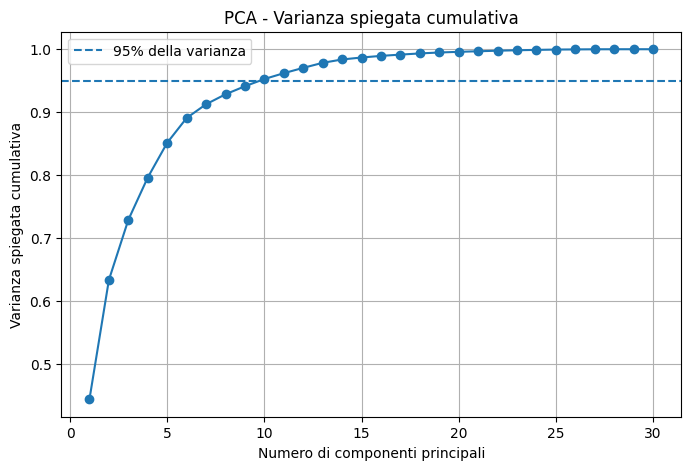

In [12]:
# Visualizzazione della varianza spiegata cumulativa

# Si crea un grafico che mostra quanta varianza totale
# viene conservata aumentando il numero di componenti principali.
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(varianza_cumulativa) + 1),
    varianza_cumulativa,
    marker="o"
)

# Si aggiunge una linea di riferimento corrispondente
# al 95% della varianza spiegata.
plt.axhline(y=0.95, linestyle="--", label="95% della varianza")

plt.xlabel("Numero di componenti principali")
plt.ylabel("Varianza spiegata cumulativa")
plt.title("PCA - Varianza spiegata cumulativa")
plt.legend()
plt.grid()

plt.show()

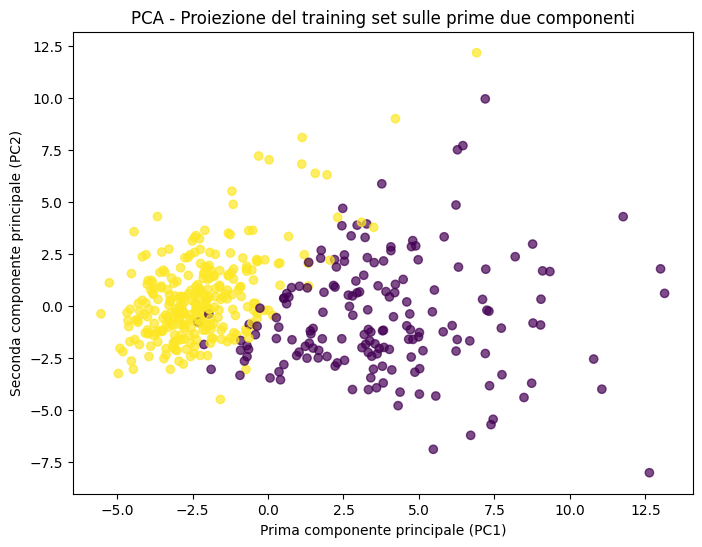

In [13]:
# Visualizzazione delle prime due componenti principali

# Si rappresentano i dati del training set utilizzando
# la prima componente principale (PC1) e la seconda (PC2).
#
# Il colore dei punti rappresenta la classe:
# 0 = malignant
# 1 = benign.

plt.figure(figsize=(8, 6))

plt.scatter(
    X_train_pca[:, 0],
    X_train_pca[:, 1],
    c=y_train,
    alpha=0.7
)

plt.xlabel("Prima componente principale (PC1)")
plt.ylabel("Seconda componente principale (PC2)")
plt.title("PCA - Proiezione del training set sulle prime due componenti")

plt.show()

In [14]:
# Riduzione del dataset a 10 componenti principali

# Dall'analisi della varianza spiegata si osserva che
# le prime 10 componenti conservano circa il 95% della
# varianza totale del dataset.
# Si applica quindi una nuova PCA mantenendo
# solamente le prime 10 componenti principali.

pca_finale = PCA(n_components=10)

# Si calcola la PCA utilizzando il training set standardizzato.
X_train_pca_finale = pca_finale.fit_transform(X_train_scaled)

# Si applica la stessa trasformazione al test set.
X_test_pca_finale = pca_finale.transform(X_test_scaled)

# Si controllano le nuove dimensioni dei dati.
print("Dimensioni X_train:", X_train_scaled.shape)
print("Dimensioni X_train dopo PCA:", X_train_pca_finale.shape)

print("Dimensioni X_test:", X_test_scaled.shape)
print("Dimensioni X_test dopo PCA:", X_test_pca_finale.shape)

# Si controlla la percentuale totale di varianza
# conservata dalle 10 componenti selezionate.
varianza_totale = pca_finale.explained_variance_ratio_.sum()

print(f"Varianza totale conservata: {varianza_totale * 100:.2f}%")

Dimensioni X_train: (455, 30)
Dimensioni X_train dopo PCA: (455, 10)
Dimensioni X_test: (114, 30)
Dimensioni X_test dopo PCA: (114, 10)
Varianza totale conservata: 95.27%


In [15]:
# Classificazione con Logistic Regression

# Si importa il classificatore Logistic Regression.
from sklearn.linear_model import LogisticRegression

# Si crea il modello.
# max_iter=1000 aumenta il numero massimo di iterazioni
# disponibili per permettere al modello di convergere.
#
# random_state=42 permette di mantenere la riproducibilità
# dell'esperimento.
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Si addestra il modello utilizzando il training set
# ridotto alle 10 componenti principali tramite PCA.
logistic_model.fit(X_train_pca_finale, y_train)

# Si utilizza il modello addestrato per effettuare
# le predizioni sul test set.
y_pred_logistic = logistic_model.predict(X_test_pca_finale)

# Si visualizzano le prime 10 classi reali
# e le prime 10 classi predette dal modello.
print("Classi reali:   ", y_test[:10])
print("Classi predette:", y_pred_logistic[:10])

Classi reali:    [0 1 0 1 0 1 1 0 0 0]
Classi predette: [0 1 0 1 0 1 1 0 0 0]


In [16]:
# Valutazione della Logistic Regression

# Si importano le metriche necessarie per valutare
# le prestazioni del classificatore.
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Si calcola l'Accuracy, cioè la percentuale
# complessiva di osservazioni classificate correttamente.
accuracy_logistic = accuracy_score(y_test, y_pred_logistic)

# Si calcola la Precision.
precision_logistic = precision_score(y_test, y_pred_logistic)

# Si calcola la Recall.
recall_logistic = recall_score(y_test, y_pred_logistic)

# Si calcola l'F1-score, che combina
# Precision e Recall in un'unica misura.
f1_logistic = f1_score(y_test, y_pred_logistic)

# Per calcolare la ROC AUC sono necessarie
# le probabilità stimate dal modello.
#
# [:, 1] seleziona la probabilità associata
# alla classe positiva, che nel dataset è la classe 1.
y_prob_logistic = logistic_model.predict_proba(
    X_test_pca_finale
)[:, 1]

# Si calcola la ROC AUC.
roc_auc_logistic = roc_auc_score(
    y_test,
    y_prob_logistic
)

# Si visualizzano i risultati.
print(f"Accuracy:  {accuracy_logistic:.4f}")
print(f"Precision: {precision_logistic:.4f}")
print(f"Recall:    {recall_logistic:.4f}")
print(f"F1-score:  {f1_logistic:.4f}")
print(f"ROC AUC:   {roc_auc_logistic:.4f}")

Accuracy:  0.9737
Precision: 0.9859
Recall:    0.9722
F1-score:  0.9790
ROC AUC:   0.9954


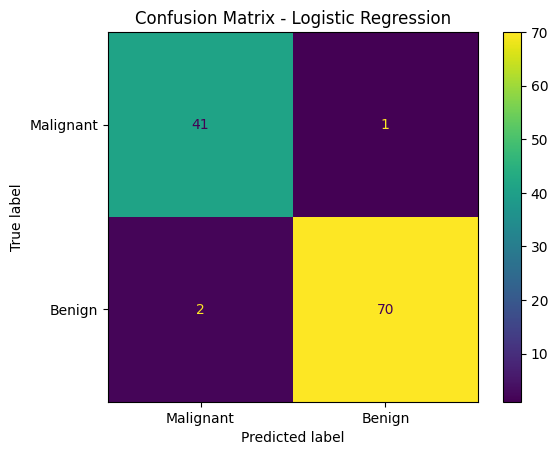

Matrice di confusione:
[[41  1]
 [ 2 70]]


In [17]:
# Matrice di confusione della Logistic Regression

# Si importano gli strumenti necessari per calcolare
# e visualizzare la matrice di confusione.
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Si calcola la matrice confrontando le classi reali
# con quelle predette dalla Logistic Regression.
cm_logistic = confusion_matrix(
    y_test,
    y_pred_logistic
)

# Si crea la rappresentazione grafica della matrice.
# Le etichette indicano le due classi del dataset:
# 0 = malignant
# 1 = benign.
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_logistic,
    display_labels=["Malignant", "Benign"]
)

# Si visualizza la matrice di confusione.
disp.plot()

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

# Si visualizzano anche i valori numerici della matrice.
print("Matrice di confusione:")
print(cm_logistic)

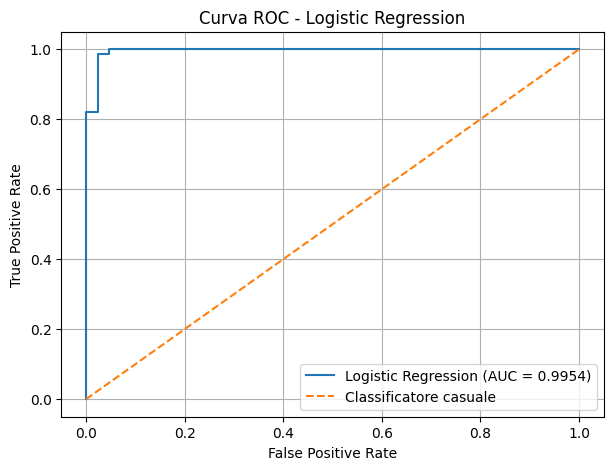

In [18]:
# Curva ROC della Logistic Regression

# Si importa la funzione roc_curve utilizzata per
# calcolare i punti necessari alla costruzione della curva ROC.
from sklearn.metrics import roc_curve

# Si calcolano:
# fpr = False Positive Rate
# tpr = True Positive Rate
#
# Per il calcolo si utilizzano le probabilità della classe positiva
# precedentemente ottenute con predict_proba().
fpr_logistic, tpr_logistic, thresholds_logistic = roc_curve(
    y_test,
    y_prob_logistic
)

# Si crea il grafico della curva ROC.
plt.figure(figsize=(7, 5))

plt.plot(
    fpr_logistic,
    tpr_logistic,
    label=f"Logistic Regression (AUC = {roc_auc_logistic:.4f})"
)

# Si aggiunge la diagonale che rappresenta
# il comportamento di un classificatore casuale.
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Classificatore casuale"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Logistic Regression")
plt.legend()
plt.grid()

plt.show()

In [19]:
# Classificazione con SVM

# Si importa il classificatore Support Vector Machine.
from sklearn.svm import SVC

# Si crea il modello SVM.
#
# kernel="rbf" utilizza il kernel Radial Basis Function.
#
# probability=True permette di ottenere le probabilità
# necessarie per il calcolo della ROC AUC e della curva ROC.
#
# random_state=42 permette di mantenere la riproducibilità
# dell'esperimento.
svm_model = SVC(
    kernel="rbf",
    probability=True,
    random_state=42
)

# Si addestra il modello utilizzando il training set
# ridotto alle 10 componenti principali tramite PCA.
svm_model.fit(X_train_pca_finale, y_train)

# Si effettuano le predizioni sul test set.
y_pred_svm = svm_model.predict(X_test_pca_finale)

# Si visualizzano le prime 10 classi reali
# e le prime 10 classi predette dal modello.
print("Classi reali:   ", y_test[:10])
print("Classi predette:", y_pred_svm[:10])

Classi reali:    [0 1 0 1 0 1 1 0 0 0]
Classi predette: [0 1 0 1 0 1 1 0 0 0]


In [20]:
# Valutazione della SVM

# Si calcola l'Accuracy, cioè la percentuale
# complessiva di osservazioni classificate correttamente.
accuracy_svm = accuracy_score(y_test, y_pred_svm)

# Si calcola la Precision.
precision_svm = precision_score(y_test, y_pred_svm)

# Si calcola la Recall.
recall_svm = recall_score(y_test, y_pred_svm)

# Si calcola l'F1-score, che combina
# Precision e Recall in un'unica misura.
f1_svm = f1_score(y_test, y_pred_svm)

# Si calcolano le probabilità associate alla classe positiva
# per poter calcolare la ROC AUC.
#
# [:, 1] seleziona la probabilità della classe 1,
# che nel dataset corrisponde alla classe benign.
y_prob_svm = svm_model.predict_proba(
    X_test_pca_finale
)[:, 1]

# Si calcola la ROC AUC.
roc_auc_svm = roc_auc_score(
    y_test,
    y_prob_svm
)

# Si visualizzano i risultati.
print(f"Accuracy:  {accuracy_svm:.4f}")
print(f"Precision: {precision_svm:.4f}")
print(f"Recall:    {recall_svm:.4f}")
print(f"F1-score:  {f1_svm:.4f}")
print(f"ROC AUC:   {roc_auc_svm:.4f}")

Accuracy:  0.9737
Precision: 0.9859
Recall:    0.9722
F1-score:  0.9790
ROC AUC:   0.9950


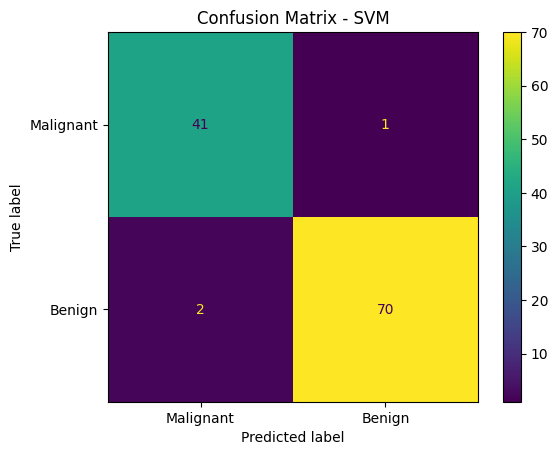

Matrice di confusione:
[[41  1]
 [ 2 70]]


In [21]:
# Matrice di confusione della SVM

# Si calcola la matrice confrontando le classi reali
# con quelle predette dalla SVM.
cm_svm = confusion_matrix(
    y_test,
    y_pred_svm
)

# Si crea la rappresentazione grafica della matrice.
# Le etichette indicano le due classi del dataset:
# 0 = malignant
# 1 = benign.
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=["Malignant", "Benign"]
)

# Si visualizza la matrice di confusione.
disp.plot()

plt.title("Confusion Matrix - SVM")
plt.show()

# Si visualizzano anche i valori numerici della matrice.
print("Matrice di confusione:")
print(cm_svm)

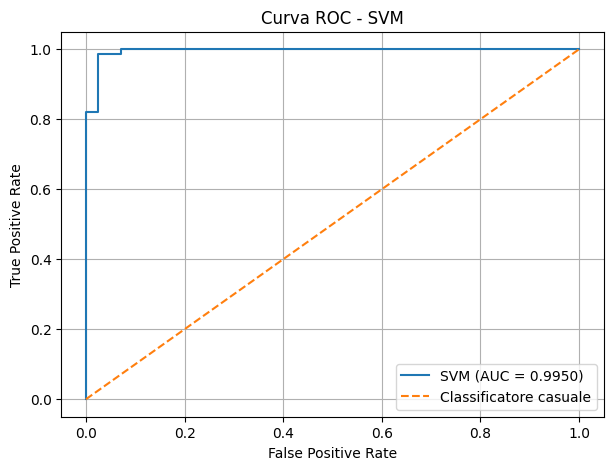

In [22]:
# Curva ROC della SVM

# Si calcolano il False Positive Rate e il True Positive Rate
# utilizzando le probabilità ottenute dalla SVM.
fpr_svm, tpr_svm, thresholds_svm = roc_curve(
    y_test,
    y_prob_svm
)

# Si crea il grafico della curva ROC.
plt.figure(figsize=(7, 5))

plt.plot(
    fpr_svm,
    tpr_svm,
    label=f"SVM (AUC = {roc_auc_svm:.4f})"
)

# Si aggiunge la diagonale che rappresenta
# il comportamento di un classificatore casuale.
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Classificatore casuale"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - SVM")
plt.legend()
plt.grid()

plt.show()

In [23]:
# Classificazione con Random Forest

# Si importa il classificatore Random Forest.
from sklearn.ensemble import RandomForestClassifier

# Si crea il modello Random Forest.
#
# n_estimators=100 indica che la foresta è composta
# da 100 alberi decisionali.
#
# random_state=42 permette di ottenere risultati
# riproducibili ad ogni esecuzione.
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Si addestra il modello utilizzando il training set
# ridotto alle 10 componenti principali tramite PCA.
random_forest_model.fit(
    X_train_pca_finale,
    y_train
)

# Si effettuano le predizioni sul test set.
y_pred_random_forest = random_forest_model.predict(
    X_test_pca_finale
)

# Si visualizzano le prime 10 classi reali
# e le prime 10 classi predette dal modello.
print("Classi reali:   ", y_test[:10])
print("Classi predette:", y_pred_random_forest[:10])

Classi reali:    [0 1 0 1 0 1 1 0 0 0]
Classi predette: [0 1 0 1 0 1 1 0 0 0]


In [24]:
# Valutazione della Random Forest

# Si calcola l'Accuracy, cioè la percentuale
# complessiva di osservazioni classificate correttamente.
accuracy_random_forest = accuracy_score(
    y_test,
    y_pred_random_forest
)

# Si calcola la Precision.
precision_random_forest = precision_score(
    y_test,
    y_pred_random_forest
)

# Si calcola la Recall.
recall_random_forest = recall_score(
    y_test,
    y_pred_random_forest
)

# Si calcola l'F1-score, che combina
# Precision e Recall in un'unica misura.
f1_random_forest = f1_score(
    y_test,
    y_pred_random_forest
)

# Si calcolano le probabilità associate alla classe positiva
# per poter calcolare la ROC AUC.
#
# [:, 1] seleziona la probabilità della classe 1,
# che nel dataset corrisponde alla classe benign.
y_prob_random_forest = random_forest_model.predict_proba(
    X_test_pca_finale
)[:, 1]

# Si calcola la ROC AUC.
roc_auc_random_forest = roc_auc_score(
    y_test,
    y_prob_random_forest
)

# Si visualizzano i risultati.
print(f"Accuracy:  {accuracy_random_forest:.4f}")
print(f"Precision: {precision_random_forest:.4f}")
print(f"Recall:    {recall_random_forest:.4f}")
print(f"F1-score:  {f1_random_forest:.4f}")
print(f"ROC AUC:   {roc_auc_random_forest:.4f}")

Accuracy:  0.9211
Precision: 0.9437
Recall:    0.9306
F1-score:  0.9371
ROC AUC:   0.9850


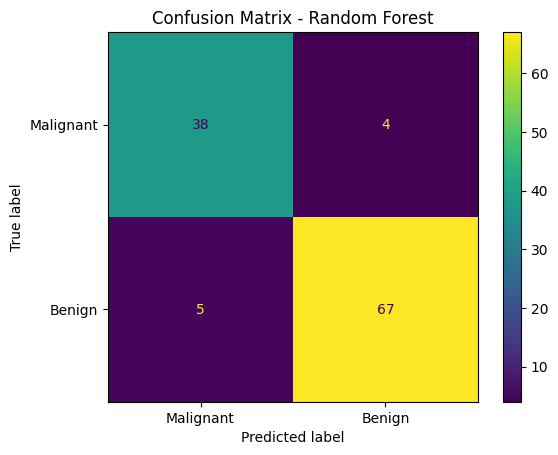

Matrice di confusione:
[[38  4]
 [ 5 67]]


In [25]:
# Matrice di confusione della Random Forest

# Si calcola la matrice confrontando le classi reali
# con quelle predette dalla Random Forest.
cm_random_forest = confusion_matrix(
    y_test,
    y_pred_random_forest
)

# Si crea la rappresentazione grafica della matrice.
# Le etichette indicano le due classi del dataset:
# 0 = malignant
# 1 = benign.
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_random_forest,
    display_labels=["Malignant", "Benign"]
)

# Si visualizza la matrice di confusione.
disp.plot()

plt.title("Confusion Matrix - Random Forest")
plt.show()

# Si visualizzano anche i valori numerici della matrice.
print("Matrice di confusione:")
print(cm_random_forest)

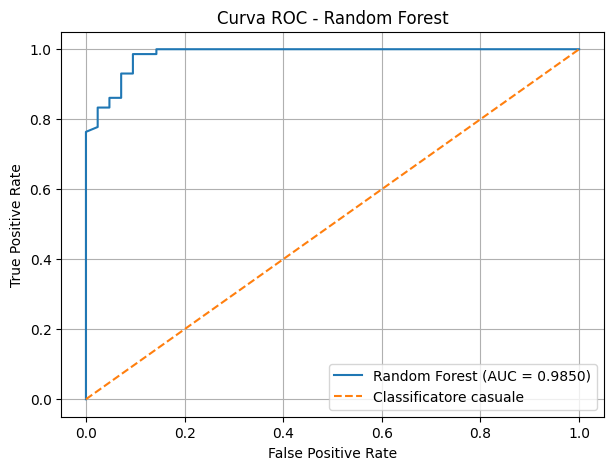

In [26]:
# Curva ROC della Random Forest

# Si calcolano il False Positive Rate e il True Positive Rate
# utilizzando le probabilità ottenute dalla Random Forest.
fpr_random_forest, tpr_random_forest, thresholds_random_forest = roc_curve(
    y_test,
    y_prob_random_forest
)

# Si crea il grafico della curva ROC.
plt.figure(figsize=(7, 5))

plt.plot(
    fpr_random_forest,
    tpr_random_forest,
    label=f"Random Forest (AUC = {roc_auc_random_forest:.4f})"
)

# Si aggiunge la diagonale che rappresenta
# il comportamento di un classificatore casuale.
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Classificatore casuale"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Random Forest")
plt.legend()
plt.grid()

plt.show()

In [27]:
# Confronto delle prestazioni dei tre classificatori

# Si crea un DataFrame contenente le metriche ottenute
# dai tre modelli sullo stesso test set.
risultati = pd.DataFrame({
    "Modello": [
        "Logistic Regression",
        "SVM",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_logistic,
        accuracy_svm,
        accuracy_random_forest
    ],
    "Precision": [
        precision_logistic,
        precision_svm,
        precision_random_forest
    ],
    "Recall": [
        recall_logistic,
        recall_svm,
        recall_random_forest
    ],
    "F1-score": [
        f1_logistic,
        f1_svm,
        f1_random_forest
    ],
    "ROC AUC": [
        roc_auc_logistic,
        roc_auc_svm,
        roc_auc_random_forest
    ]
})

# Si imposta il nome del modello come indice della tabella.
risultati = risultati.set_index("Modello")

# Si visualizzano i risultati arrotondati
# a quattro cifre decimali.
risultati.round(4)

,Accuracy,Precision,Recall,F1-score,ROC AUC
Modello,,,,,
Logistic Regression,0.9737,0.9859,0.9722,0.9790,0.9954
SVM,0.9737,0.9859,0.9722,0.9790,0.9950
Random Forest,0.9211,0.9437,0.9306,0.9371,0.9850


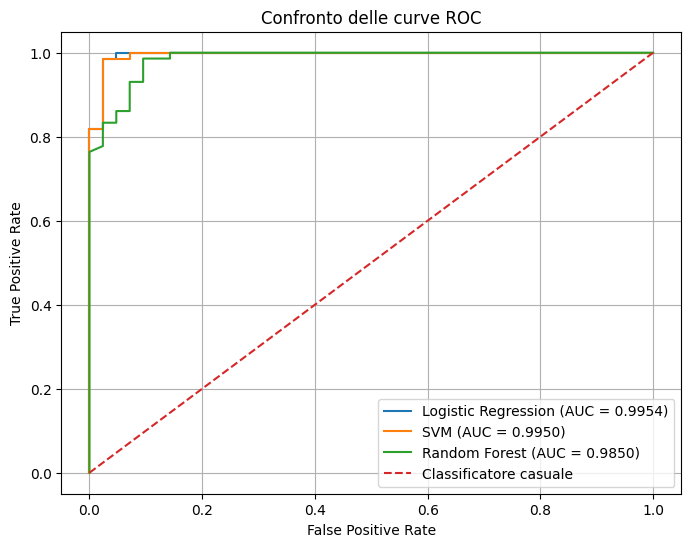

In [28]:
# Confronto delle curve ROC dei tre classificatori

# Si crea un unico grafico contenente le curve ROC
# di Logistic Regression, SVM e Random Forest.
plt.figure(figsize=(8, 6))

plt.plot(
    fpr_logistic,
    tpr_logistic,
    label=f"Logistic Regression (AUC = {roc_auc_logistic:.4f})"
)

plt.plot(
    fpr_svm,
    tpr_svm,
    label=f"SVM (AUC = {roc_auc_svm:.4f})"
)

plt.plot(
    fpr_random_forest,
    tpr_random_forest,
    label=f"Random Forest (AUC = {roc_auc_random_forest:.4f})"
)

# Si aggiunge la diagonale che rappresenta
# il comportamento di un classificatore casuale.
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Classificatore casuale"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Confronto delle curve ROC")
plt.legend()
plt.grid()

plt.show()

In [29]:
# Installazione e importazione di SHAP

# Si installa la libreria SHAP, utilizzata per
# analizzare e spiegare le predizioni del modello.
!pip install shap -q

# Si importa la libreria SHAP.
import shap

print("Versione SHAP:", shap.__version__)

Versione SHAP: 0.52.0


In [30]:
# Calcolo dei valori SHAP per la Random Forest

# Si crea un oggetto TreeExplainer, specifico per
# i modelli basati su alberi come Random Forest.
explainer = shap.TreeExplainer(
    random_forest_model
)

# Si calcolano i valori SHAP sul test set
# trasformato tramite PCA.
shap_values = explainer(
    X_test_pca_finale
)

# Si controllano le dimensioni dei valori SHAP ottenuti.
print("Dimensioni SHAP:", shap_values.values.shape)

Dimensioni SHAP: (114, 10, 2)


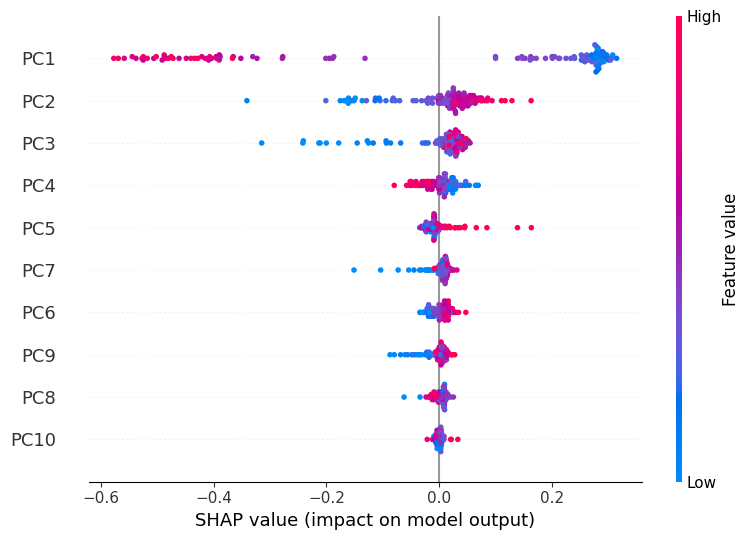

In [31]:
# Visualizzazione dei valori SHAP della Random Forest

# Si selezionano i valori SHAP relativi alla classe 1,
# che nel dataset corrisponde alla classe benign.
shap_values_benign = shap_values[:, :, 1]

# Si creano i nomi delle 10 componenti principali
# utilizzate come input della Random Forest.
nomi_componenti = [
    f"PC{i+1}" for i in range(10)
]

# Si visualizza il summary plot.
#
# Il grafico mostra quali componenti principali
# hanno avuto maggiore influenza sulle predizioni
# effettuate dalla Random Forest.
shap.summary_plot(
    shap_values_benign.values,
    X_test_pca_finale,
    feature_names=nomi_componenti
)